# 📊 Matplotlib — Hands-On Practice
## Data Visualization from Scratch

---

**What is Matplotlib?**
Matplotlib is Python's foundational plotting library. Every other viz library (Seaborn, Pandas plots) is built on top of it.

**Core concepts:**
| Term | What It Is |
|---|---|
| `Figure` | The entire canvas / window |
| `Axes` | A single plot within the figure |
| `Subplot` | Multiple axes arranged in a grid |
| `Artist` | Everything drawn: lines, text, patches |

**This notebook covers:**
1. Line Plot — Trend over time
2. Bar Chart — Comparing categories
3. Horizontal Bar Chart — Ranked list
4. Scatter Plot — Relationship between two variables
5. Histogram — Distribution of data
6. Pie Chart — Part-to-whole breakdown
7. Subplots — Multiple charts in one figure
8. Customization — Colors, fonts, styles, annotations
9. Box Plot — Distribution with outliers
10. Heatmap (imshow) — 2D data grid

---
> 💡 Each cell produces a chart — run with **Shift + Enter**

---
## Example 1: Line Plot — Monthly Sales Trend

Best for showing change over time.

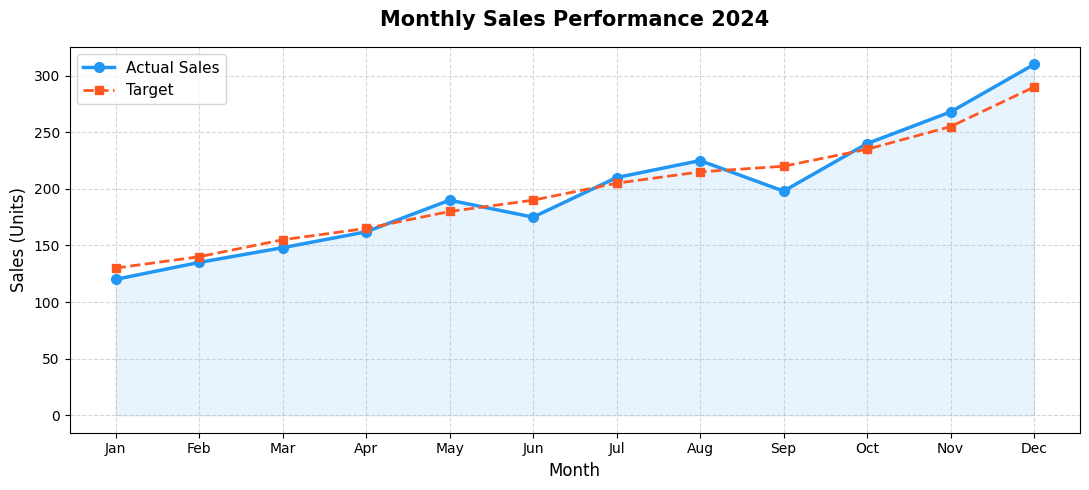

Observations: Sales exceeded target in Q4. Growth trend visible from July.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sales   = [120, 135, 148, 162, 190, 175, 210, 225, 198, 240, 268, 310]
targets = [130, 140, 155, 165, 180, 190, 205, 215, 220, 235, 255, 290]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(months, sales,   color='#2196F3', linewidth=2.5, marker='o',
        markersize=7, label='Actual Sales')
ax.plot(months, targets, color='#FF5722', linewidth=2, linestyle='--',
        marker='s', markersize=6, label='Target')

# Fill area under actual sales
ax.fill_between(months, sales, alpha=0.10, color='#2196F3')

ax.set_title('Monthly Sales Performance 2024', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales (Units)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("Observations: Sales exceeded target in Q4. Growth trend visible from July.")

---
## Example 2: Bar Chart — Department Revenue Comparison

Best for comparing values across discrete categories.

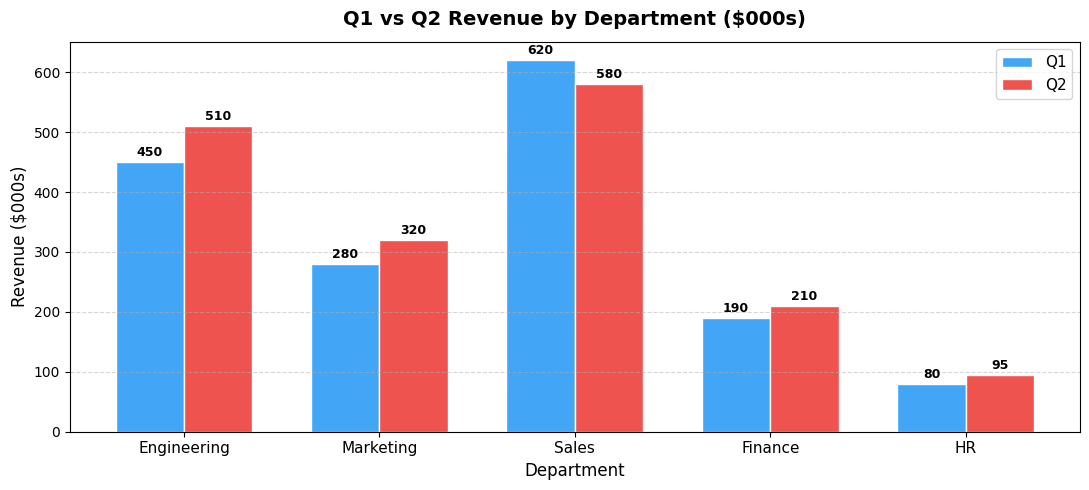

In [2]:
import matplotlib.pyplot as plt
import numpy as np

departments = ['Engineering', 'Marketing', 'Sales', 'Finance', 'HR']
q1_revenue  = [450, 280, 620, 190, 80]
q2_revenue  = [510, 320, 580, 210, 95]

x = np.arange(len(departments))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2, q1_revenue, width, label='Q1', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x + width/2, q2_revenue, width, label='Q2', color='#EF5350', edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Q1 vs Q2 Revenue by Department ($000s)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Revenue ($000s)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(departments, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Example 3: Horizontal Bar Chart — Top Products Ranked

Best when category names are long, or you want a ranking.

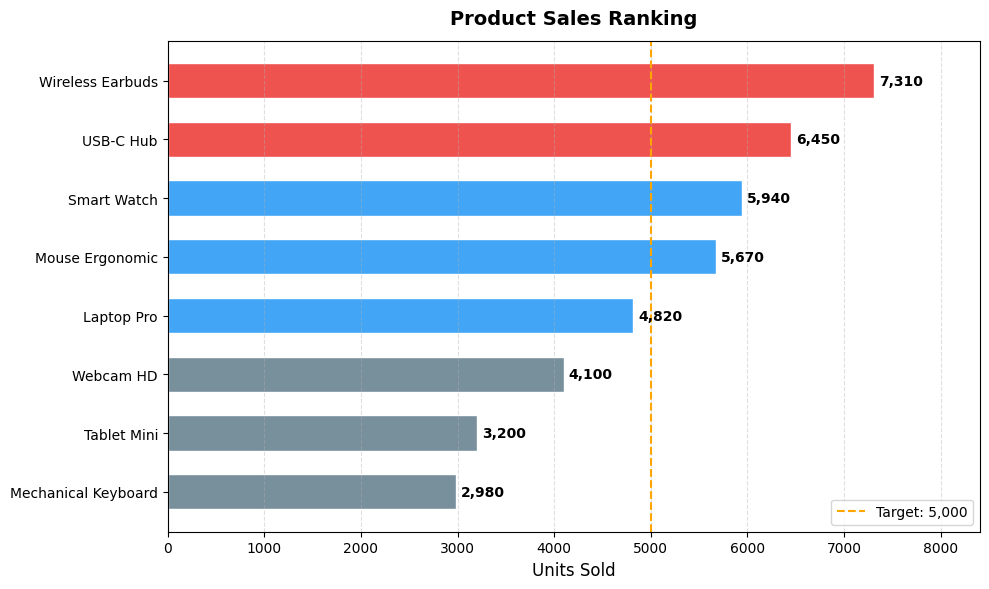

Red bars = above 6,000 units | Blue = above 4,500 | Grey = below 4,500


In [3]:
import matplotlib.pyplot as plt

products = ['Laptop Pro', 'Wireless Earbuds', 'Smart Watch', 'Tablet Mini',
            'USB-C Hub', 'Mechanical Keyboard', 'Webcam HD', 'Mouse Ergonomic']
units_sold = [4820, 7310, 5940, 3200, 6450, 2980, 4100, 5670]

# Sort descending
sorted_pairs = sorted(zip(units_sold, products))
units_sorted, prods_sorted = zip(*sorted_pairs)

colors = ['#EF5350' if u > 6000 else '#42A5F5' if u > 4500 else '#78909C'
          for u in units_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prods_sorted, units_sorted, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, units_sorted):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Product Sales Ranking', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Units Sold', fontsize=12)
ax.axvline(x=5000, color='orange', linestyle='--', linewidth=1.5, label='Target: 5,000')
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(units_sorted) * 1.15)
plt.tight_layout()
plt.show()
print("Red bars = above 6,000 units | Blue = above 4,500 | Grey = below 4,500")

---
## Example 4: Scatter Plot — Experience vs Salary

Best for showing relationship / correlation between two numerical variables.

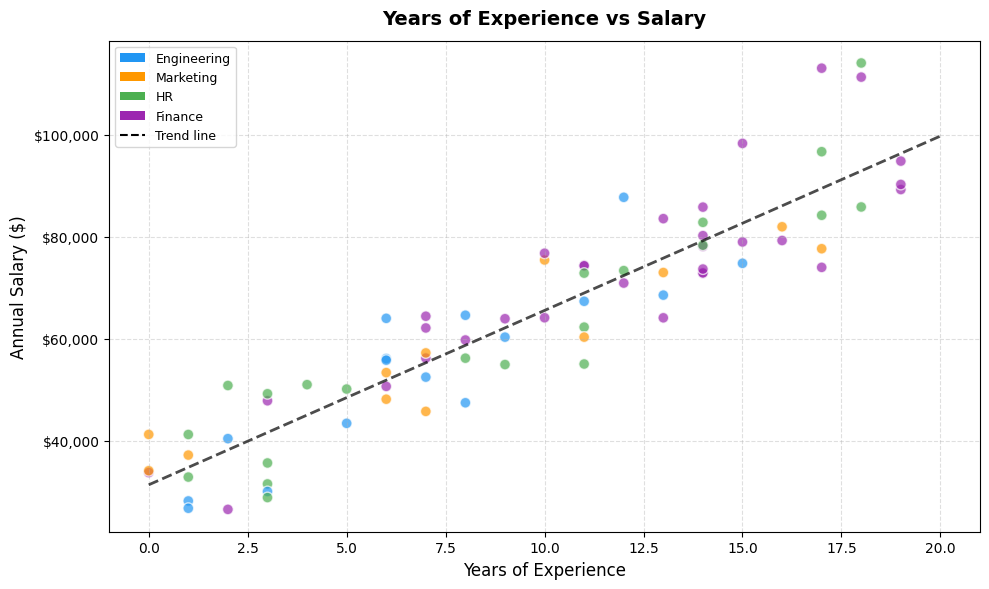

In [4]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
experience = np.random.randint(0, 20, 80)
salary     = 30000 + experience * 3500 + np.random.normal(0, 8000, 80)
dept       = np.random.choice(['Engineering','Marketing','HR','Finance'], 80)

dept_colors = {'Engineering':'#2196F3', 'Marketing':'#FF9800', 'HR':'#4CAF50', 'Finance':'#9C27B0'}
colors_list = [dept_colors[d] for d in dept]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(experience, salary, c=colors_list, alpha=0.7, s=60, edgecolors='white')

# Add trend line
z = np.polyfit(experience, salary, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 20, 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, alpha=0.7, label=f'Trend (slope≈{z[0]:,.0f}/yr)')

# Custom legend for departments
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=d) for d, c in dept_colors.items()]
legend_elements.append(plt.Line2D([0],[0], color='k', linestyle='--', label='Trend line'))
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax.set_title('Years of Experience vs Salary', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Annual Salary ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Example 5: Histogram — Score Distribution

Best for seeing the distribution (spread) of a single numerical variable.

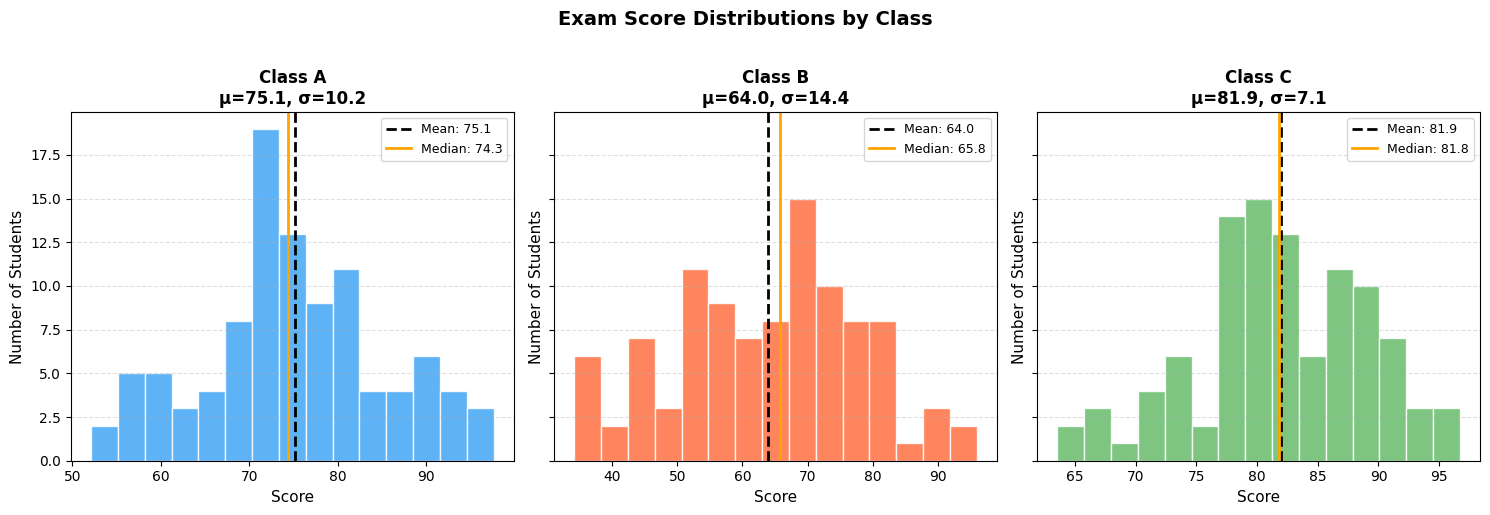

In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(7)
# Simulate exam scores for 3 classes
class_a = np.random.normal(loc=75, scale=10, size=100).clip(0, 100)
class_b = np.random.normal(loc=65, scale=15, size=100).clip(0, 100)
class_c = np.random.normal(loc=82, scale=8,  size=100).clip(0, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, scores, label, color in zip(axes,
    [class_a, class_b, class_c],
    ['Class A', 'Class B', 'Class C'],
    ['#42A5F5', '#FF7043', '#66BB6A']):

    ax.hist(scores, bins=15, color=color, edgecolor='white', alpha=0.85)

    # Add mean and median lines
    ax.axvline(scores.mean(),   color='black',  linestyle='--', linewidth=2,
               label=f'Mean: {scores.mean():.1f}')
    ax.axvline(np.median(scores), color='orange', linestyle='-',  linewidth=2,
               label=f'Median: {np.median(scores):.1f}')

    ax.set_title(f'{label}\nμ={scores.mean():.1f}, σ={scores.std():.1f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Number of Students', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Exam Score Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Example 6: Pie Chart — Market Share

Best for showing part-to-whole proportions (use sparingly — max 5-6 slices).

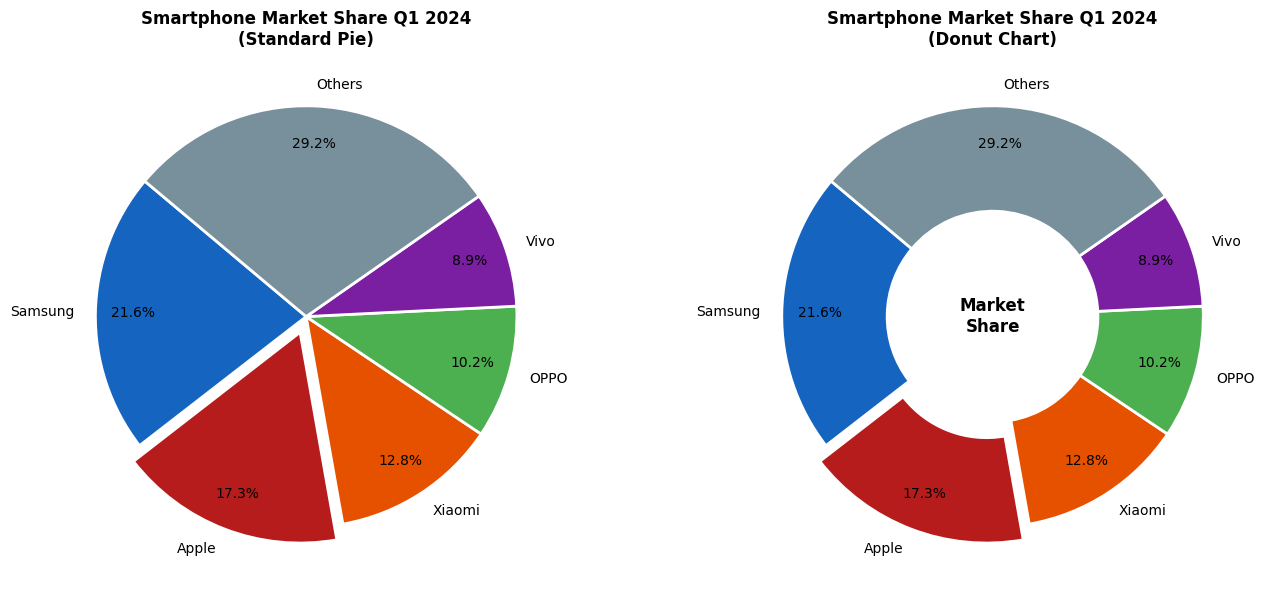

In [6]:
import matplotlib.pyplot as plt

labels  = ['Samsung', 'Apple', 'Xiaomi', 'OPPO', 'Vivo', 'Others']
sizes   = [21.6, 17.3, 12.8, 10.2, 8.9, 29.2]
explode = (0, 0.08, 0, 0, 0, 0)   # explode Apple slice
colors  = ['#1565C0','#B71C1C','#E65100','#4CAF50','#7B1FA2','#78909C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Standard pie
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
            explode=explode, colors=colors, pctdistance=0.82,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Smartphone Market Share Q1 2024\n(Standard Pie)', fontsize=12, fontweight='bold')

# Right: Donut chart (pie with a hole)
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
            explode=explode, colors=colors, pctdistance=0.82,
            wedgeprops={'edgecolor':'white','linewidth':2, 'width':0.5})
axes[1].text(0, 0, 'Market\nShare', ha='center', va='center', fontsize=12, fontweight='bold')
axes[1].set_title('Smartphone Market Share Q1 2024\n(Donut Chart)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Example 7: Subplots — Dashboard Layout

Combine multiple charts in one figure for a dashboard view.

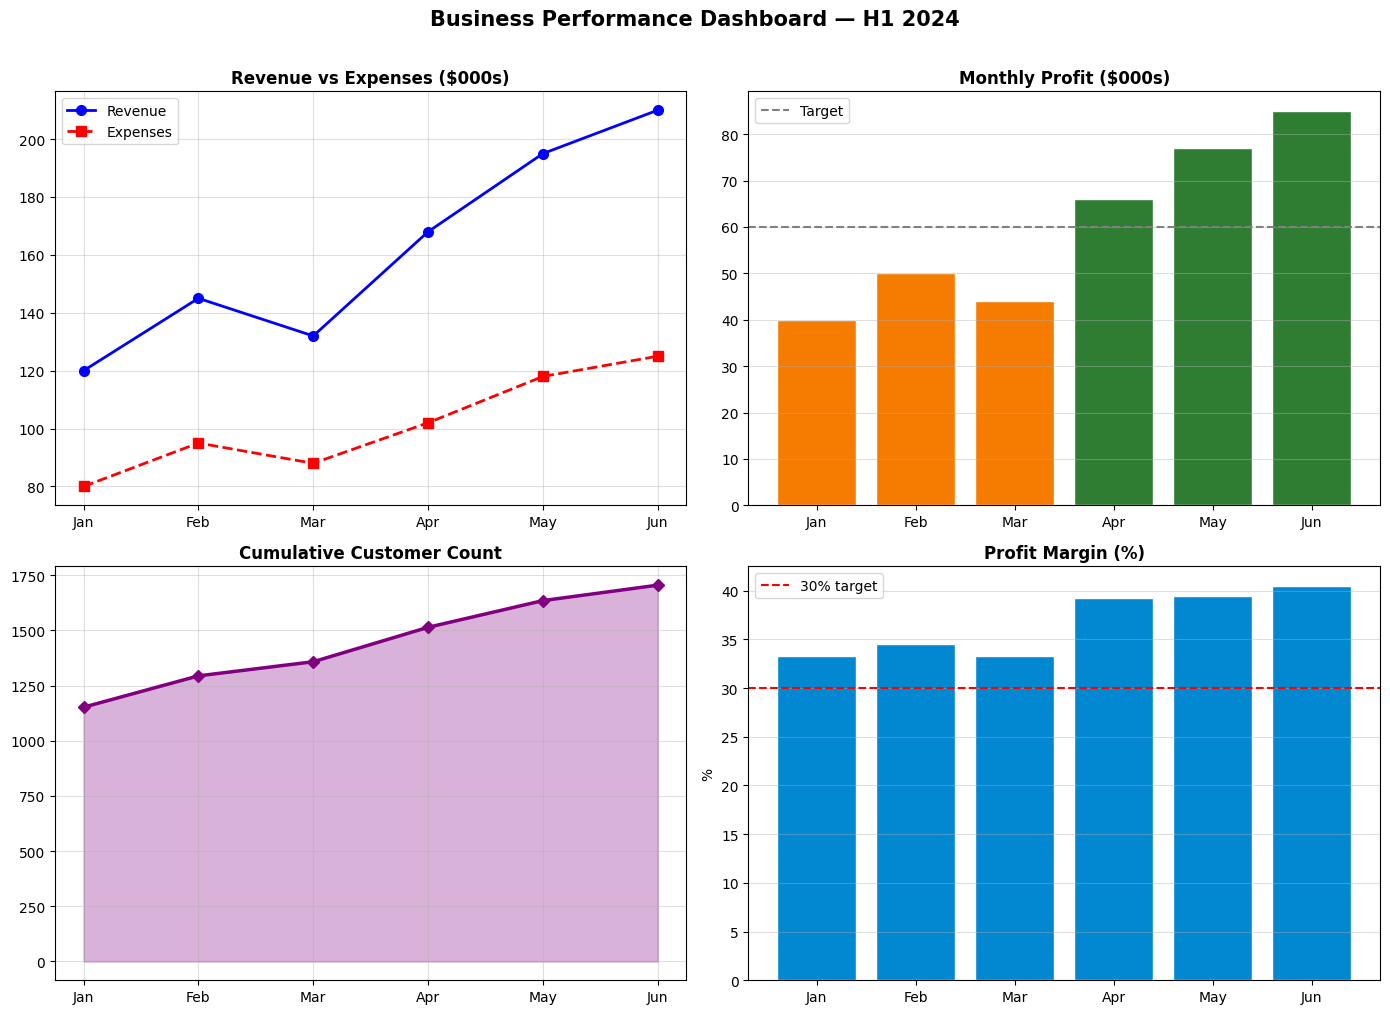

In [7]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
months   = ['Jan','Feb','Mar','Apr','May','Jun']
revenue  = [120, 145, 132, 168, 195, 210]
expenses = [80,  95,  88,  102, 118, 125]
profit   = [r-e for r,e in zip(revenue,expenses)]
cust_growth = np.cumsum(np.random.randint(50,200,6)) + 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Business Performance Dashboard — H1 2024',
             fontsize=15, fontweight='bold', y=1.01)

# Top-left: Revenue vs Expenses line
axes[0,0].plot(months, revenue,  'b-o', linewidth=2, markersize=7, label='Revenue')
axes[0,0].plot(months, expenses, 'r--s', linewidth=2, markersize=7, label='Expenses')
axes[0,0].set_title('Revenue vs Expenses ($000s)', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.4)

# Top-right: Profit bar
colors_bar = ['#2e7d32' if p > 60 else '#f57c00' for p in profit]
axes[0,1].bar(months, profit, color=colors_bar, edgecolor='white')
axes[0,1].axhline(60, color='gray', linestyle='--', linewidth=1.5, label='Target')
axes[0,1].set_title('Monthly Profit ($000s)', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.4)

# Bottom-left: Customer growth area chart
axes[1,0].fill_between(months, cust_growth, alpha=0.3, color='purple')
axes[1,0].plot(months, cust_growth, 'purple', linewidth=2.5, marker='D', markersize=6)
axes[1,0].set_title('Cumulative Customer Count', fontweight='bold')
axes[1,0].grid(True, alpha=0.4)

# Bottom-right: Profit margin %
margins = [p/r*100 for p,r in zip(profit,revenue)]
axes[1,1].bar(months, margins, color='#0288D1', edgecolor='white')
axes[1,1].axhline(30, color='red', linestyle='--', linewidth=1.5, label='30% target')
axes[1,1].set_title('Profit Margin (%)', fontweight='bold')
axes[1,1].set_ylabel('%')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Example 8: Customization — Colors, Annotations, Styles

Making charts publication-ready with custom styling and annotations.

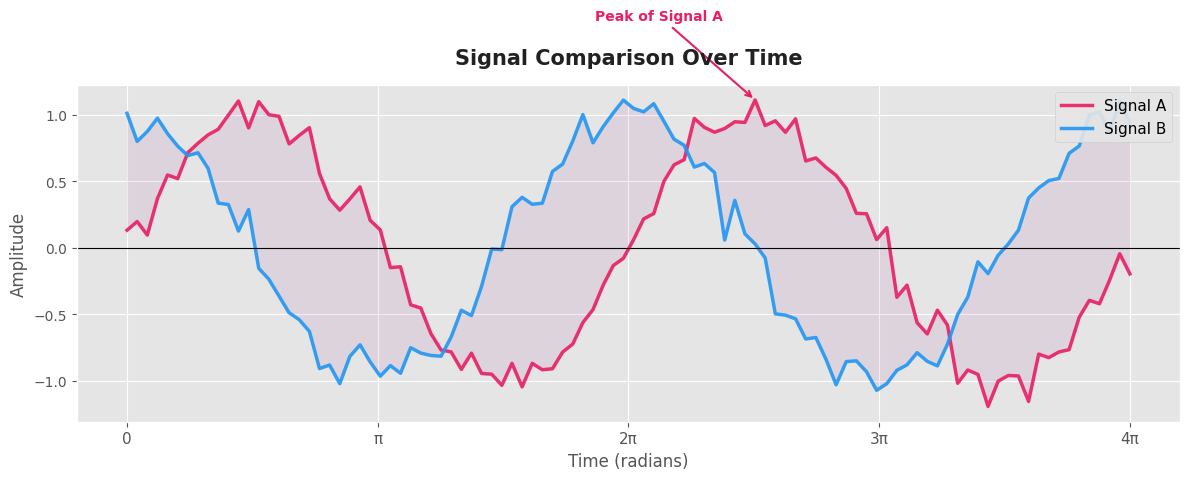

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Use a built-in style
plt.style.use('ggplot')

np.random.seed(10)
x = np.linspace(0, 4*np.pi, 100)
y1 = np.sin(x) + np.random.normal(0, 0.1, 100)
y2 = np.cos(x) + np.random.normal(0, 0.1, 100)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, y1, color='#E91E63', linewidth=2.5, label='Signal A', alpha=0.9)
ax.plot(x, y2, color='#2196F3', linewidth=2.5, label='Signal B', alpha=0.9)

# Shaded region
ax.fill_between(x, y1, y2, alpha=0.08, color='purple')

# Annotations
peak_idx = np.argmax(y1)
ax.annotate('Peak of Signal A',
            xy=(x[peak_idx], y1[peak_idx]),
            xytext=(x[peak_idx]-2, y1[peak_idx]+0.6),
            fontsize=10, fontweight='bold', color='#E91E63',
            arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.5))

# Zero line
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Titles and labels with custom fonts
ax.set_title('Signal Comparison Over Time', fontsize=15, fontweight='bold',
             color='#212121', pad=15)
ax.set_xlabel('Time (radians)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Custom tick labels
ax.set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
ax.set_xticklabels(['0', 'π', '2π', '3π', '4π'], fontsize=11)

plt.tight_layout()
plt.show()
plt.style.use('default')  # Reset style

---
## Example 9: Box Plot — Distribution with Outliers

Best for comparing distributions across groups and spotting outliers.

C:\Users\manik\AppData\Local\Temp\ipykernel_12284\1702537364.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_list, patch_artist=True, labels=labels,


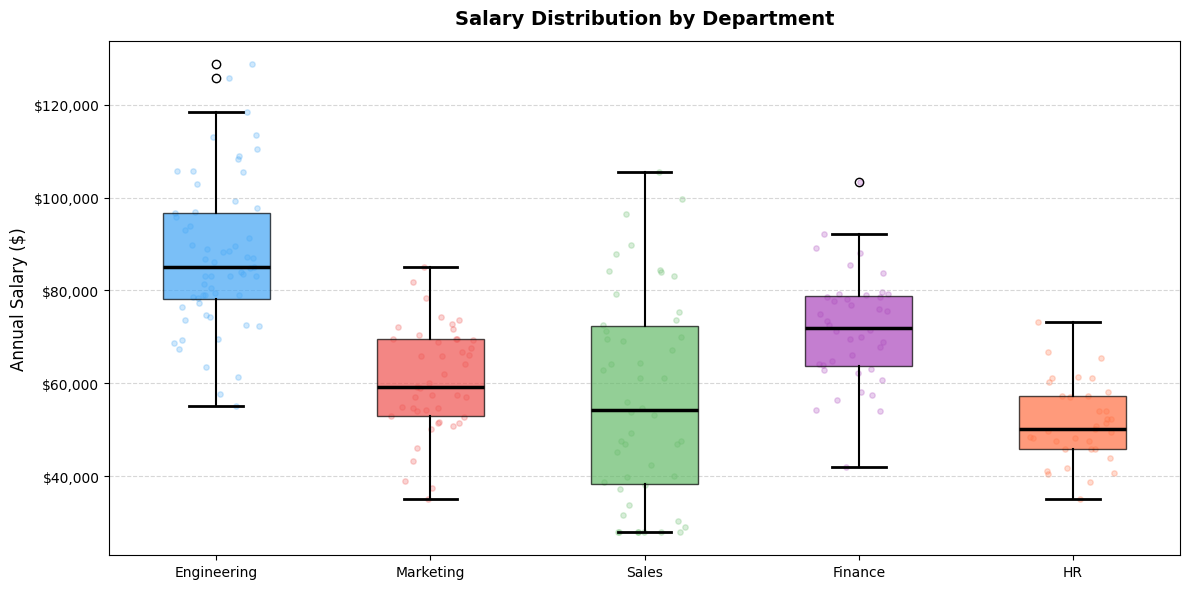

Box = IQR (25th to 75th percentile) | Line = median | Points outside whiskers = outliers


In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(5)
# Salary data by department
departments = {
    'Engineering': np.random.normal(85000, 18000, 60).clip(40000, 150000),
    'Marketing'  : np.random.normal(60000, 12000, 45).clip(35000, 110000),
    'Sales'      : np.random.normal(55000, 20000, 50).clip(28000, 120000),
    'Finance'    : np.random.normal(72000, 14000, 40).clip(42000, 130000),
    'HR'         : np.random.normal(52000, 10000, 35).clip(35000,  95000),
}

data_list = list(departments.values())
labels    = list(departments.keys())
colors    = ['#42A5F5','#EF5350','#66BB6A','#AB47BC','#FF7043']

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(data_list, patch_artist=True, labels=labels,
                medianprops={'color':'black','linewidth':2.5},
                whiskerprops={'linewidth':1.5},
                capprops={'linewidth':2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay data points (jittered)
for i, (data, color) in enumerate(zip(data_list, colors), 1):
    jitter = np.random.uniform(-0.2, 0.2, len(data))
    ax.scatter(np.full(len(data), i) + jitter, data,
               alpha=0.25, s=15, color=color)

ax.set_title('Salary Distribution by Department', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Annual Salary ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("Box = IQR (25th to 75th percentile) | Line = median | Points outside whiskers = outliers")

---
## Example 10: Heatmap with imshow — Correlation Grid

Visualize 2D numerical data as a color grid.

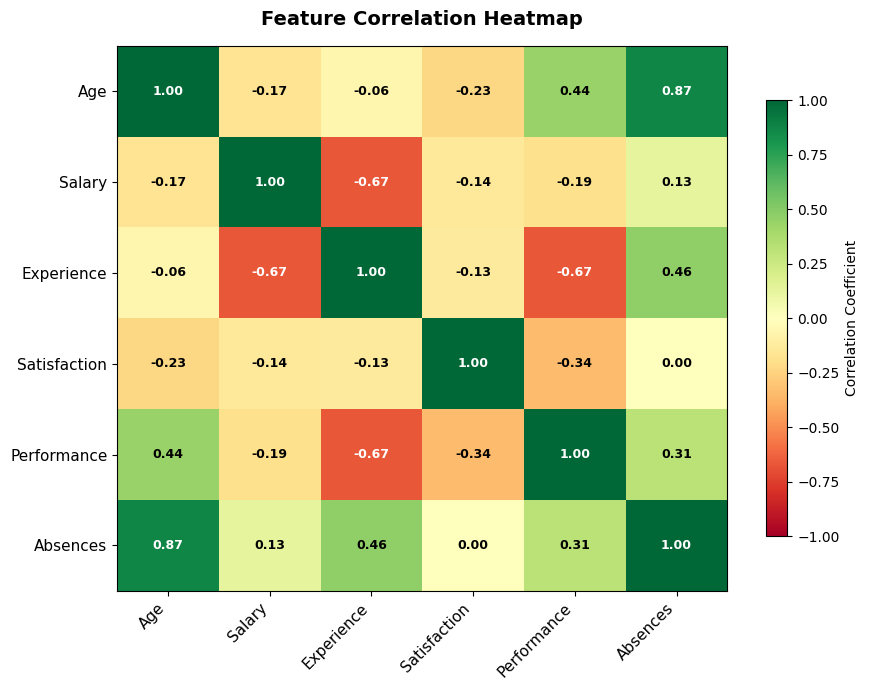

Green = positive correlation | Red = negative | Yellow = no correlation


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix (like what pandas .corr() produces)
features = ['Age', 'Salary', 'Experience', 'Satisfaction', 'Performance', 'Absences']
n = len(features)

# Create a symmetric correlation matrix
np.random.seed(3)
raw = np.random.uniform(-1, 1, (n, n))
corr_matrix = (raw + raw.T) / 2
np.fill_diagonal(corr_matrix, 1.0)
# Clip to valid range
corr_matrix = np.clip(corr_matrix, -1, 1)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation Coefficient')

# Axis labels
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(features, fontsize=11)

# Annotate each cell with the value
for i in range(n):
    for j in range(n):
        val = corr_matrix[i, j]
        text_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("Green = positive correlation | Red = negative | Yellow = no correlation")

---
## 📝 Assignment — 5 Questions for Practice

Try these on your own. Write your solution in new cells below each question.

---

**Q1. Line Plot**
Create a line chart showing the population of 3 countries (India, USA, China) over 5 years (2020–2024).
Use a different color and marker style for each country. Add a legend, grid, axis labels, and title.

---

**Q2. Bar Chart**
Create a grouped bar chart comparing monthly website traffic (in thousands) across Mobile, Desktop, and Tablet for January through June.
Add value labels on top of each bar and a horizontal target line at 50,000 visitors.

---

**Q3. Scatter Plot + Trend Line**
Generate 100 random data points representing student study hours (x: 1–10 hours/day) and exam scores (y: 40–100).
Make scores loosely correlated with hours. Plot a scatter chart and add a polynomial trend line.
Color points by score range: green (≥80), orange (60–79), red (<60).

---

**Q4. Histogram**
Simulate ages of 500 employees (use a normal distribution, mean=38, std=9, clipped 22–65).
Plot a histogram with 20 bins. Add vertical lines for the mean, median, and the 25th/75th percentiles.
Label each line clearly in the legend.

---

**Q5. Dashboard (2×2 Subplots)**
Build a 4-panel figure showing any dataset of your choice:
- Panel 1: Line chart (trend)
- Panel 2: Bar chart (comparison)
- Panel 3: Scatter plot (relationship)
- Panel 4: Pie or donut chart (composition)

Add a shared title for the figure and individual titles for each panel.

---
*Tip: Use `plt.tight_layout()` to prevent overlapping. Save your best chart with `plt.savefig('my_chart.png', dpi=150)`.*